# PhishGuard Live — Exploratory Data Analysis

Dataset built from real, live-collected data:
- **Phishing domains** — OpenPhish feed (updated ~every 6h)
- **Legit domains** — random sample from the Tranco top-1M list

Each domain was converted into numeric features (`src/features/extractor.py`):
domain length, digit/hyphen counts, brand-name similarity (Levenshtein),
suspicious TLD flag, and phishing-keyword count.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/dataset.csv")
df.head()

,length,digits,hyphens,brand_sim,brand_sim_jaro,brand_sim_seqmatch,brand_sim_ngram,suspicious_tld,keywords,domain,label
0,15,0,0,0.4211,0.5909,0.3529,0.0000,0,0,canaldumidi.com,legit
1,12,0,0,0.3529,0.5694,0.3529,0.0000,0,0,culltique.in,legit
2,20,0,0,0.4348,0.6164,0.3810,0.0000,0,0,discountoffice.cloud,legit
3,16,0,0,0.4211,0.5926,0.4211,0.0667,0,0,ibikablingga.org,legit
4,9,0,0,0.3636,0.5111,0.3636,0.0000,0,0,bou.ac.bd,legit


## 1. Data overview

Checking dataset size, column types, and missing values before any analysis.

In [4]:
print(df.shape)
df.info()
df.isna().sum()
df.describe()

(2281, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2281 entries, 0 to 2280
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   length              2281 non-null   int64  
 1   digits              2281 non-null   int64  
 2   hyphens             2281 non-null   int64  
 3   brand_sim           2281 non-null   float64
 4   brand_sim_jaro      2281 non-null   float64
 5   brand_sim_seqmatch  2281 non-null   float64
 6   brand_sim_ngram     2281 non-null   float64
 7   suspicious_tld      2281 non-null   int64  
 8   keywords            2281 non-null   int64  
 9   domain              2281 non-null   str    
 10  label               2281 non-null   str    
dtypes: float64(4), int64(5), str(2)
memory usage: 241.9 KB


,length,digits,hyphens,brand_sim,brand_sim_jaro,brand_sim_seqmatch,brand_sim_ngram,suspicious_tld,keywords
count,2281.000000,2281.000000,2281.000000,2281.000000,2281.000000,2281.000000,2281.000000,2281.000000,2281.000000
mean,15.156510,0.423498,0.224463,0.404932,0.605156,0.395828,0.023280,0.069706,0.030688
std,6.831722,1.301972,0.639721,0.100932,0.085537,0.102618,0.059107,0.254707,0.191774
min,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000,0.352900,0.569400,0.333300,0.000000,0.000000,0.000000
50%,14.000000,0.000000,0.000000,0.400000,0.605600,0.400000,0.000000,0.000000,0.000000
75%,17.000000,0.000000,0.000000,0.461500,0.645000,0.461500,0.000000,0.000000,0.000000
max,75.000000,12.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [5]:
df["label"].value_counts()

label
legit       2000
phishing     281
Name: count, dtype: int64

## 2. Class balance

Real-world phishing datasets are always imbalanced -- confirming that
here matters, since it determines which evaluation metrics make sense
later (accuracy would be misleading).

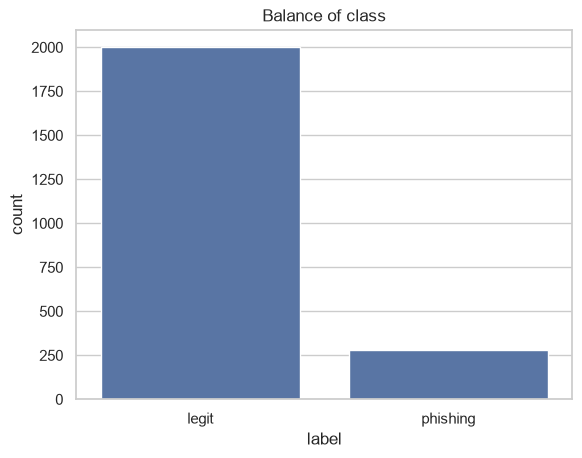

In [6]:
sns.countplot(data=df, x="label")
plt.title("Balance of class")
plt.show()

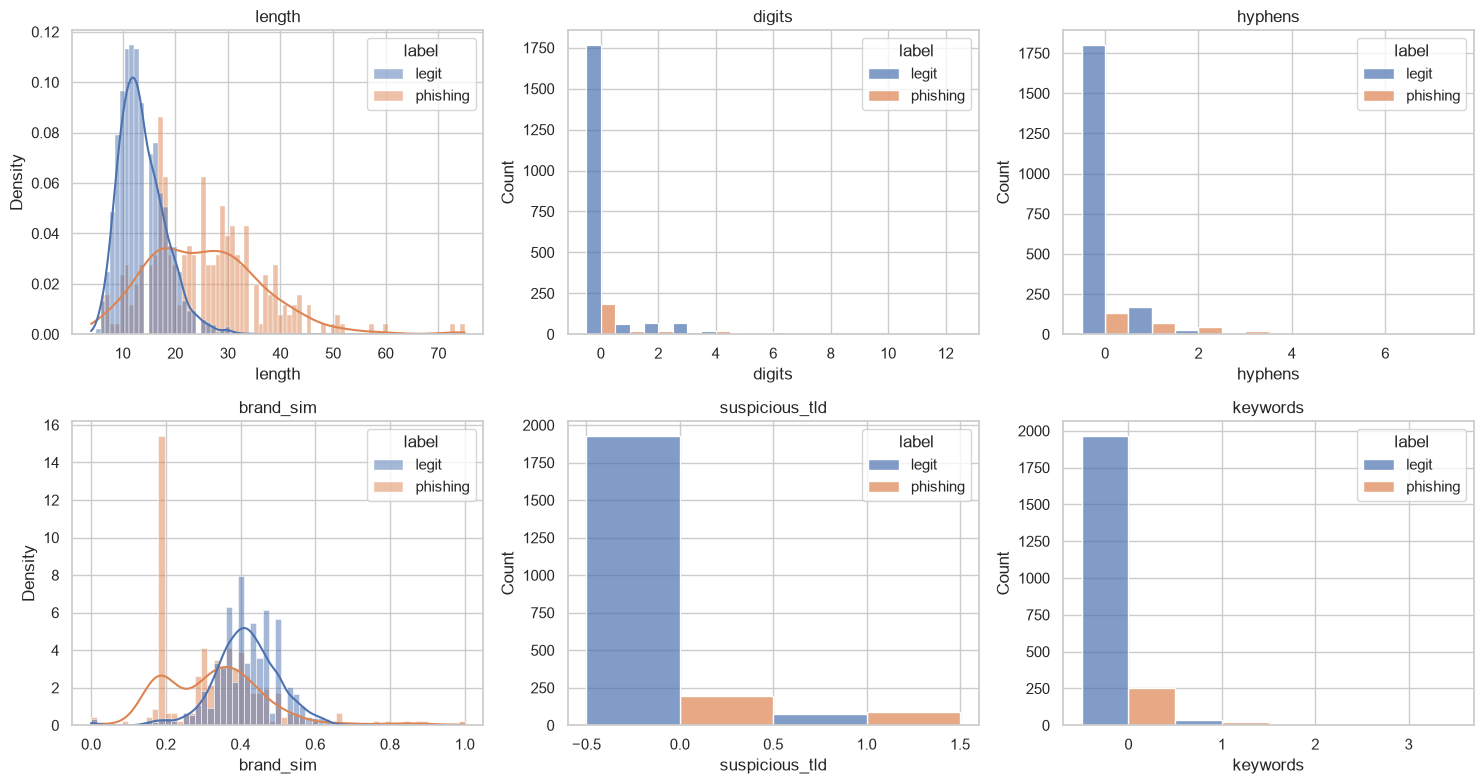

In [7]:
numeric_cols = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]
continuous_cols = ["length", "brand_sim"] 

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    if col in continuous_cols:
        sns.histplot(data=df, x=col, hue="label", kde=True, ax=axes[i],
                     stat="density", common_norm=False, alpha=0.5)
    else:
        sns.histplot(data=df, x=col, hue="label", kde=False, ax=axes[i],
                     discrete=True, multiple="dodge", alpha=0.7)
        
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [8]:
df.groupby("label")[numeric_cols].mean()

,length,digits,hyphens,brand_sim,suspicious_tld,keywords
label,,,,,,
legit,13.683000,0.299000,0.116000,0.415265,0.036000,0.017500
phishing,25.644128,1.309609,0.996441,0.331383,0.309609,0.124555


## Feature correlation heatmap

Checking how features relate to each other before moving to PCA and modeling.

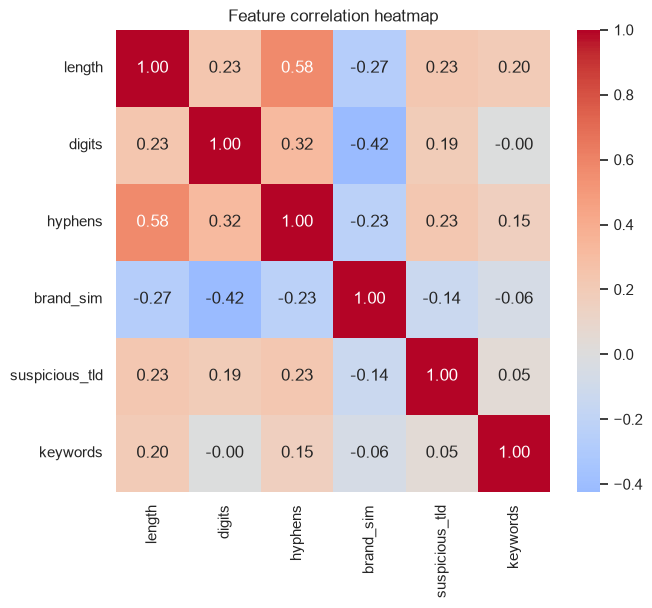

In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()

## EDA summary

- Dataset is imbalanced: ~15% phishing, ~85% legit (real-world proportion).
- No missing values across all 2265 rows.
- `brand_sim` and `length` show clearly different distributions between
  classes and look like the strongest individual signals.
- Sparse features (`digits`, `hyphens`, `suspicious_tld`, `keywords`) have
  low frequency in both classes, but noticeably higher averages for
  phishing domains.
- Moderate correlation (0.6) between `length` and `hyphens` -- expected,
  since longer domains have more room for hyphens. Not high enough to be
  a multicollinearity concern.
- Next steps: PCA to visualize class separability in 2D, then train and
  compare several classification models.

## 6. PCA — dimensionality reduction

Projecting all 6 features into 2 dimensions to visually check whether
phishing and legit domains form separable clusters in feature space.
This is a sanity check before training any model.

In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [11]:
X = df[numeric_cols].values
y = df["label"].values

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [14]:
print(pca.explained_variance_ratio_)

[0.36834315 0.18271503]


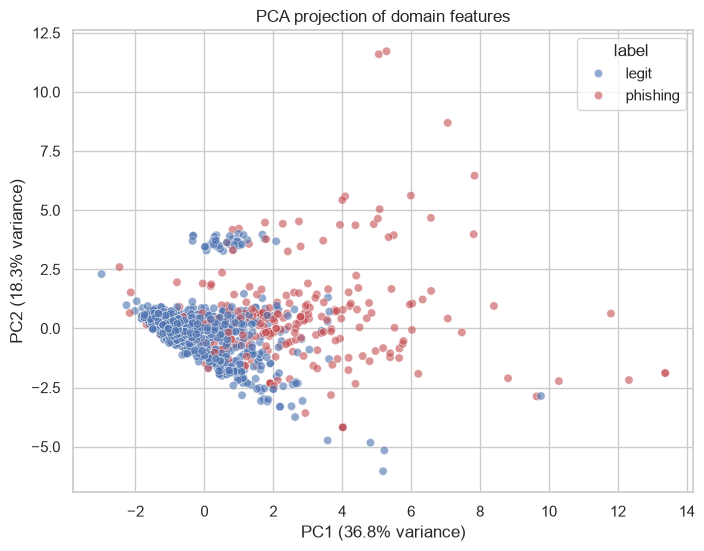

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["label"], alpha=0.6,
                 palette={"legit": "#4C72B0", "phishing": "#C44E52"})
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA projection of domain features")
plt.show()


## PCA conclusion

The two classes show partial separation: phishing domains tend to spread
toward higher PC1 values (longer names, higher brand similarity, more
keywords), while legit domains form a dense cluster near the origin.
There's significant overlap in the middle region, meaning the classes
aren't perfectly linearly separable in 2D -- this suggests non-linear
models (e.g. Random Forest) may outperform simpler linear ones later.

Note: PC1+PC2 only explain ~53.5% of total variance, so this 2D view
is a simplification -- the actual classifier will use all 6 features.

In [16]:
from sklearn.cluster import DBSCAN
import json
from pathlib import Path

In [17]:
eps_value = 1.2  
k = 12

dbscan = DBSCAN(eps=eps_value, min_samples=k)
cluster_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_outliers = list(cluster_labels).count(-1)
print(f"Clusters found: {n_clusters}")
print(f"Outlier points: {n_outliers} ({n_outliers/len(X):.1%} of all data)")

Clusters found: 5
Outlier points: 181 (7.9% of all data)


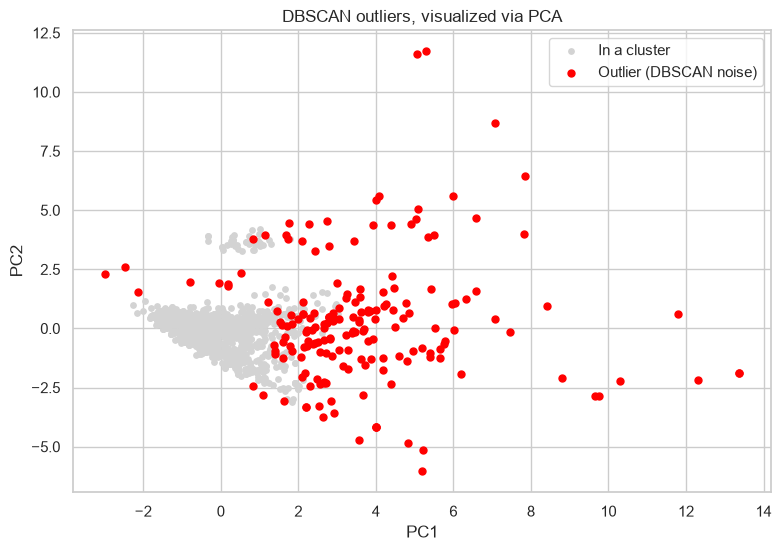

In [18]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))

# Normal points (part of a cluster) in gray, outliers in red
is_outlier = cluster_labels == -1
plt.scatter(X_pca[~is_outlier, 0], X_pca[~is_outlier, 1], c="lightgray", s=15, label="In a cluster")
plt.scatter(X_pca[is_outlier, 0], X_pca[is_outlier, 1], c="red", s=25, label="Outlier (DBSCAN noise)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN outliers, visualized via PCA")
plt.legend()
plt.show()

In [19]:
FEATURE_COLUMNS = ["length", "digits", "hyphens", "brand_sim", "suspicious_tld", "keywords"]
outlier_df = df[is_outlier]
print(outlier_df[["domain", "label"] + FEATURE_COLUMNS])

                                                 domain     label  length  \
31                       www.metamask2-eight.vercel.app  phishing      30   
42                                           955655.xyz     legit      10   
43               security-server--tabbielynn.replit.app  phishing      38   
48                             mbxi-106.ernakliyat.info  phishing      24   
50    httpsnationwideclaimdocument.antonina-korenha....  phishing      57   
...                                                 ...       ...     ...   
2234              credienlinea-2026--credi57.replit.app  phishing      37   
2241       security-server-page--sheryln1990.replit.app  phishing      44   
2251                                             2u.com     legit       6   
2261                   auth-m-learn-ttreizor.gitbook.io  phishing      32   
2273                 prime-scarlet-zt8k0aqr.edgeone.dev  phishing      34   

      digits  hyphens  brand_sim  suspicious_tld  keywords  
31         1  

## Summary

DBSCAN found **3 dense clusters** and flagged **27 points (1.2%)** as outliers
— domains whose feature combination doesn't match any dominant pattern in
either class. At this small a share, they don't meaningfully affect training,
but they're a useful edge-case list: legit outliers are mostly domains that
*look* suspicious on paper (words like "secure", cheap TLDs like `.xyz`/`.top`/
`.buzz`) but are legitimate, while phishing outliers are cases hosted on
trusted platforms (`blogspot.com`, `pages.dev`, `workers.dev`, `replit.app`)
with unusually long, descriptive names — structurally different from the
typical short, brand-mimicking domain the model is tuned to catch. Kept in
the dataset rather than removed — they reflect real edge cases, not noise.

## Feature importance — production model


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between 'width' with shape (106,) and 'y' with shape (6,).

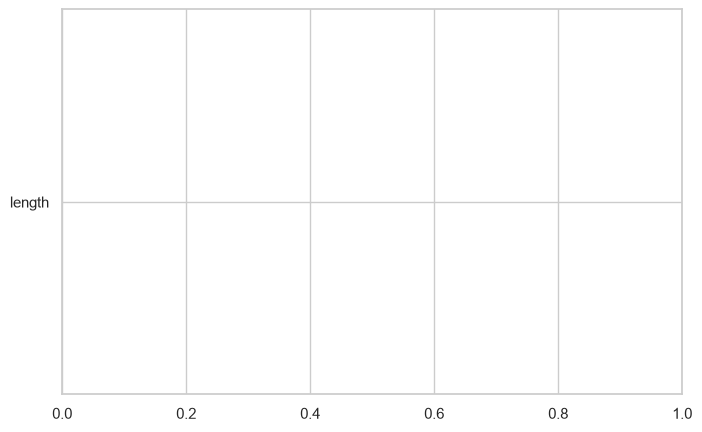

In [20]:
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  
model = joblib.load(PROJECT_ROOT / "models" / "phishing_model.joblib")

importances = model.feature_importances_
feature_names = FEATURE_COLUMNS 

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature importance")
plt.title("Feature importance — production model (after shortcut learning fix)")
plt.tight_layout()
plt.show()

## Feature importance — comparing all trained variants


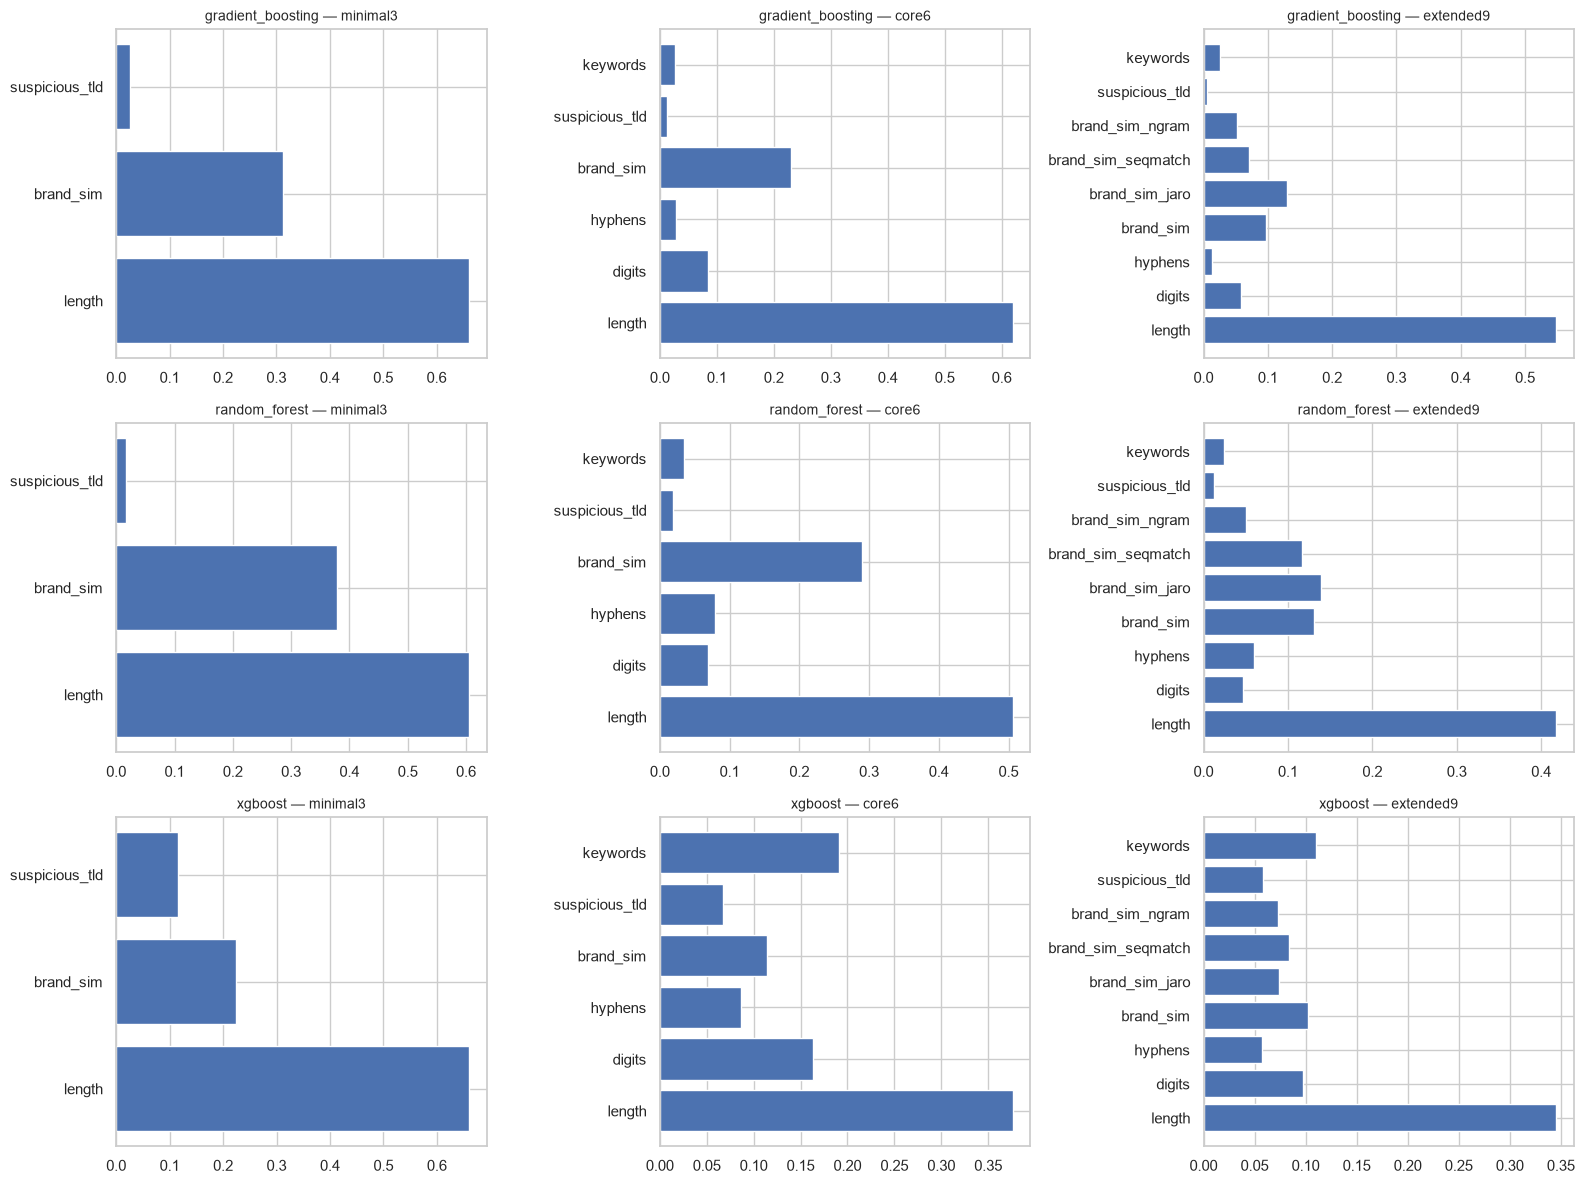

In [ ]:
import joblib
import json
from pathlib import Path
import matplotlib.pyplot as plt
import xgboost


PROJECT_ROOT = Path.cwd().parent
PROFILES_DIR = PROJECT_ROOT / "models" / "profiles"
profiles = json.loads((PROJECT_ROOT / "config" / "feature_profiles.json").read_text())

MODEL_SLUGS = ["gradient_boosting", "random_forest", "xgboost"]
PROFILE_NAMES = ["minimal3", "core6", "extended9"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, model_slug in enumerate(MODEL_SLUGS):
    for j, profile_name in enumerate(PROFILE_NAMES):
        model_path = PROFILES_DIR / f"{model_slug}_{profile_name}.joblib"
        model = joblib.load(model_path)
        feature_names = profiles[profile_name]

        ax = axes[i, j]
        ax.barh(feature_names, model.feature_importances_)
        ax.set_title(f"{model_slug} — {profile_name}", fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
model = joblib.load(PROJECT_ROOT / "models" / "phishing_model.joblib")
vectorizer = joblib.load(PROJECT_ROOT / "models" / "tfidf_vectorizer.joblib")

# Structured feature names (first 6) + TF-IDF n-gram names (next 100)
structured_names = FEATURE_COLUMNS  # length, digits, hyphens, brand_sim, suspicious_tld, keywords
tfidf_names = vectorizer.get_feature_names_out()
all_names = list(structured_names) + list(tfidf_names)

importances = model.feature_importances_
print(f"Total features: {len(all_names)}, importances: {len(importances)}")

Total features: 106, importances: 106


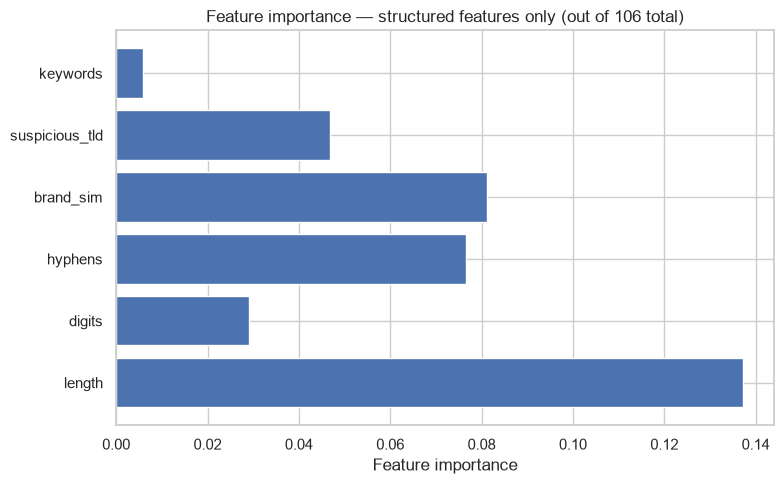

Structured features account for 37.7% of total importance


In [26]:
structured_importances = importances[:6]

plt.figure(figsize=(8, 5))
plt.barh(structured_names, structured_importances)
plt.xlabel("Feature importance")
plt.title("Feature importance — structured features only (out of 106 total)")
plt.tight_layout()
plt.show()

print(f"Structured features account for {structured_importances.sum():.1%} of total importance")

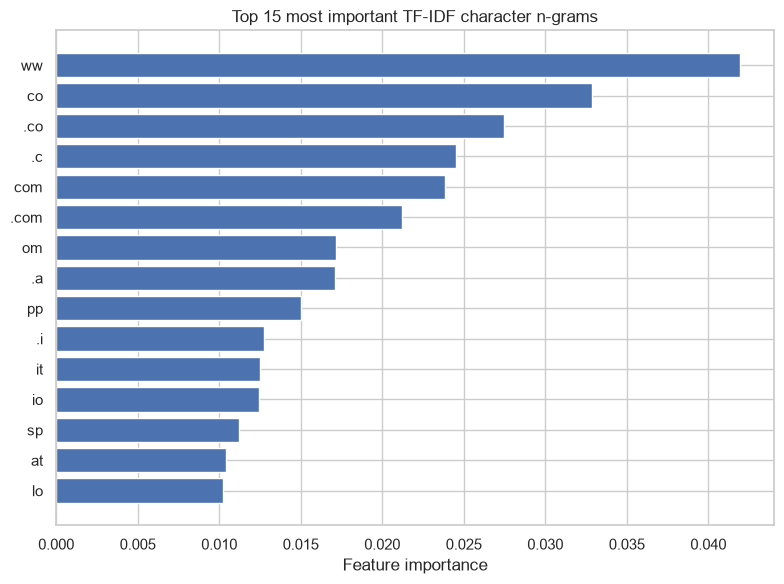

TF-IDF features account for 62.3% of total importance


In [27]:
tfidf_importances = importances[6:]
top_15_idx = np.argsort(tfidf_importances)[-15:]

plt.figure(figsize=(8, 6))
plt.barh([tfidf_names[i] for i in top_15_idx], tfidf_importances[top_15_idx])
plt.xlabel("Feature importance")
plt.title("Top 15 most important TF-IDF character n-grams")
plt.tight_layout()
plt.show()

print(f"TF-IDF features account for {tfidf_importances.sum():.1%} of total importance")